<a href="https://colab.research.google.com/github/siddharth10-dev/machine_learning_practs/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [50]:
import matplotlib.pyplot as plt

In [16]:
import seaborn as sns

In [3]:
%matplotlib inline

In [52]:
df=pd.read_csv('USA_Housing_100_Rows.csv')

In [53]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,77450.712295,3.876944,7.429345,3.34,15866.868094,1515402.93,"1000 Maple Street, City 0"
1,67926.035482,5.369032,7.672941,3.55,27807.499725,1680963.69,"1001 Maple Street, City 1"
2,79715.328072,5.485928,8.299661,4.60,35062.924397,1548328.71,"1002 Maple Street, City 2"
3,92845.447846,4.796584,8.264562,4.49,35563.767125,1811667.41,"1003 Maple Street, City 3"
4,66487.699379,5.758071,5.346797,3.98,29599.214342,1313443.93,"1004 Maple Street, City 4"


<Axes: >

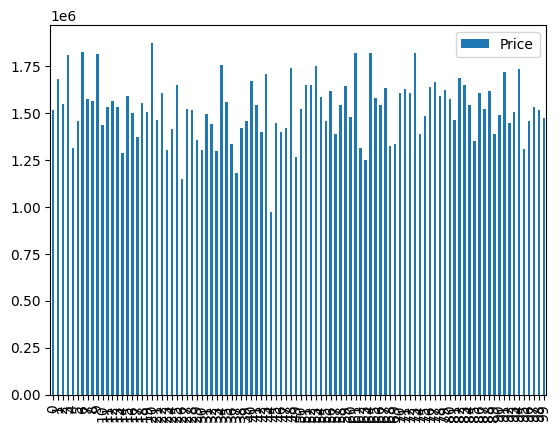

In [54]:
df.plot.bar(y='Price')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              100 non-null    float64
 1   Avg. Area House Age           100 non-null    float64
 2   Avg. Area Number of Rooms     100 non-null    float64
 3   Avg. Area Number of Bedrooms  100 non-null    float64
 4   Area Population               100 non-null    float64
 5   Price                         100 non-null    float64
 6   Address                       100 non-null    object 
dtypes: float64(6), object(1)
memory usage: 5.6+ KB


In [56]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,100.000000,100.000000,100.000000,100.00000,100.000000,1.000000e+02
mean,68442.302239,6.032654,7.077876,4.08560,34327.946354,1.522189e+06
std,13622.526420,1.428231,1.301139,0.70723,12764.763863,1.627892e+05
min,30703.823439,3.121843,3.110479,2.30000,7376.946023,9.745633e+05
25%,60986.414942,4.791509,6.213468,3.54750,24299.796360,1.422466e+06
50%,68095.655623,6.126161,7.117235,4.04000,34089.205180,1.527469e+06
75%,76089.280780,6.807256,7.845325,4.55000,42817.401193,1.624124e+06
max,97784.172768,10.000000,11.623278,5.75000,71946.569701,1.876164e+06


In [57]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

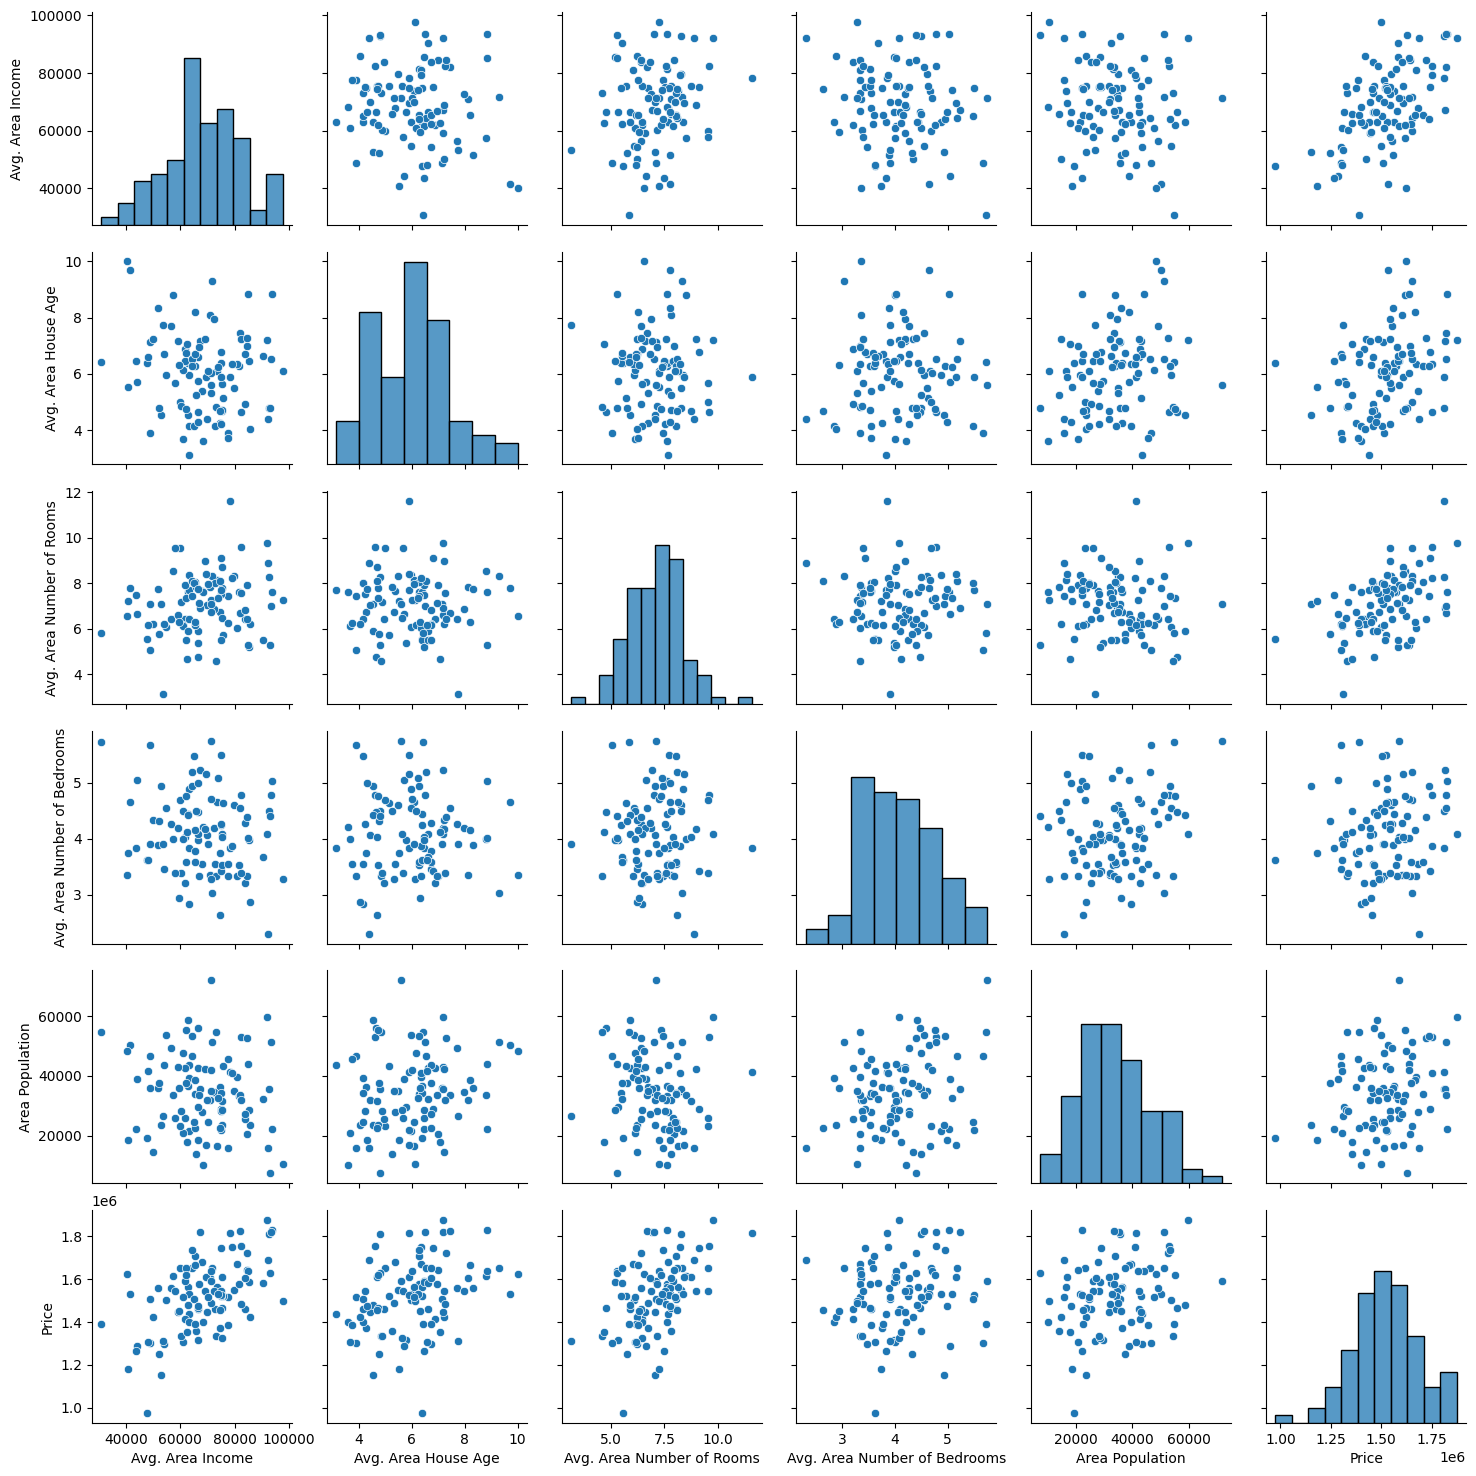

In [58]:
sns.pairplot(df)

/tmp/ipykernel_2116/834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

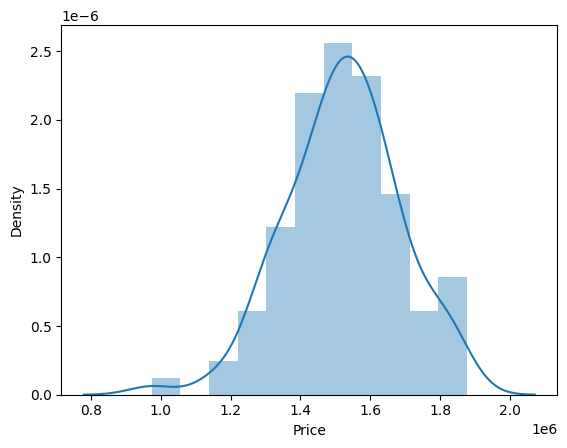

In [59]:
sns.distplot(df['Price'])

In [60]:
df.corr

<bound method DataFrame.corr of     Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       77450.712295             3.876944                   7.429345   
1       67926.035482             5.369032                   7.672941   
2       79715.328072             5.485928                   8.299661   
3       92845.447846             4.796584                   8.264562   
4       66487.699379             5.758071                   5.346797   
..               ...                  ...                        ...   
95      48047.275778             6.577976                   6.168508   
96      74441.804156             4.674214                   8.079520   
97      73915.829083             6.230588                   7.368759   
98      70076.701850             6.087313                   7.975435   
99      66481.192999             4.285545                   7.755555   

    Avg. Area Number of Bedrooms  Area Population       Price  \
0                           3.34     15866.868094  1515402.93   
1                           3.55     27807.499725  1680963.69   
2                           4.60     35062.924397  1548328.71   
3                           4.49     35563.767125  1811667.41   
4                           3.98     29599.214342  1313443.93   
..                           ...              ...         ...   
95                          3.62     41466.920524  1306993.35   
96                          2.63     22553.046148  1456125.78   
97                          5.08     32715.935863  1530461.89   
98                          3.91     24492.580959  1514297.38   
99                          4.99     18406.403228  1472523.30   

                       Address  
0    1000 Maple Street, City 0  
1    1001 Maple Street, City 1  
2    1002 Maple Street, City 2  
3    1003 Maple Street, City 3  
4    1004 Maple Street, City 4  
..                         ...  
95  1095 Maple Street, City 15  
96  1096 Maple Street, City 16  
97  1097 Maple Street, City 17  
98  1098 Maple Street, City 18  
99  1099 Maple Street, City 19  

[100 rows x 7 columns]>

<Axes: >

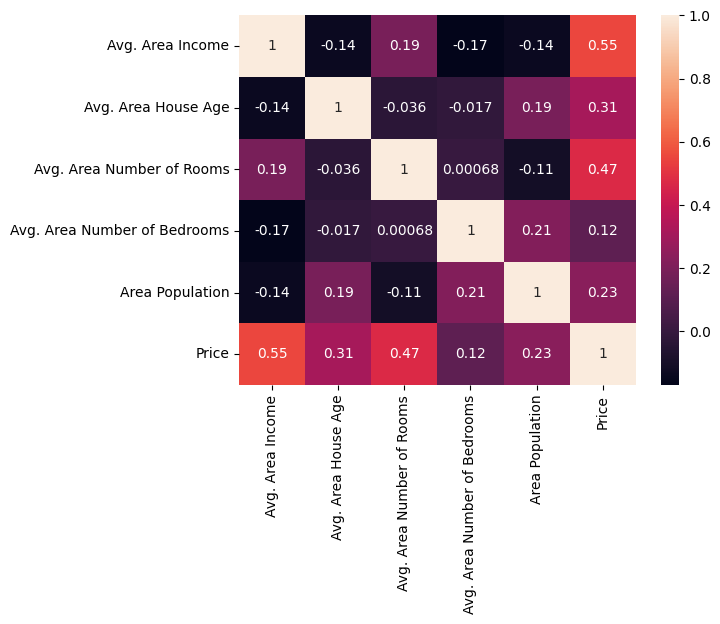

In [61]:
sns.heatmap(df.drop('Address',axis=1).corr(),annot=True)

In [62]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [63]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]

In [64]:
Y=df['Price']

In [65]:
from sklearn.model_selection import train_test_split


In [66]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=101)

In [67]:
from sklearn.linear_model import LinearRegression

In [68]:
lm=LinearRegression()


In [69]:
lm.fit(X_train,Y_train)

LinearRegression()

In [70]:
print(lm.intercept_)

32412.58483824297


In [71]:
lm.coef_

array([7.10389361e+00, 4.90463278e+04, 4.95820417e+04, 5.43961800e+04,
       4.15334560e+00])

In [72]:
cdf=pd.DataFrame(lm.coef_,X.columns,columns=['Coeff'])

In [73]:
cdf.head()

,Coeff
Avg. Area Income,7.103894
Avg. Area House Age,49046.327819
Avg. Area Number of Rooms,49582.041663
Avg. Area Number of Bedrooms,54396.179981
Area Population,4.153346


In [77]:
predictions=lm.predict(X_test)

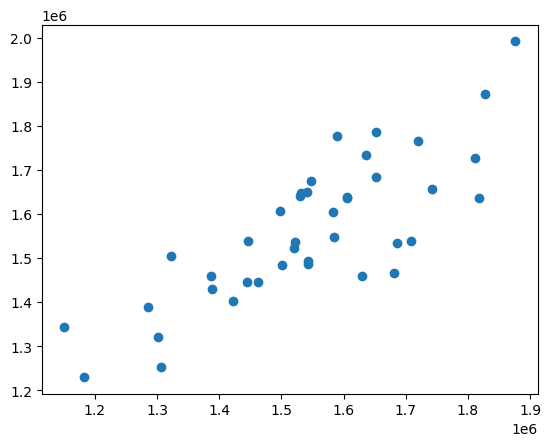

In [78]:
plt.scatter(Y_test,predictions)

/tmp/ipykernel_2116/293656646.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Y_test-predictions))


<Axes: xlabel='Price', ylabel='Density'>

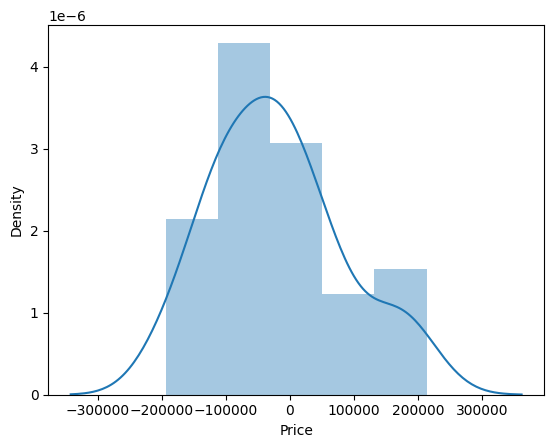

In [79]:
sns.distplot((Y_test-predictions))

In [80]:
from sklearn import metrics

In [81]:
metrics.mean_absolute_error(Y_test,predictions)

85111.50108929096

In [82]:
metrics.mean_squared_error(Y_test,predictions)

10874994759.346954

In [83]:
metrics.root_mean_squared_error(Y_test,predictions)

104283.24294605991